# Exercise 1
Render a single triangle in a simple scene of your choice. Make sure your intersection tests work correctly using this as a test.


In [48]:
from __future__ import annotations
from dataclasses import dataclass
import math

#define a 3D vector class with basic operations and some common vector functions

from typing import Union

@dataclass(frozen=True)
class Vec3:
    x: float
    y: float
    z: float

    def __add__(self, o: "Vec3") -> "Vec3": return Vec3(self.x + o.x, self.y + o.y, self.z + o.z)
    def __sub__(self, o: "Vec3") -> "Vec3": return Vec3(self.x - o.x, self.y - o.y, self.z - o.z)

    def __mul__(self, k: Union[float, "Vec3"]) -> "Vec3":
        # scalar multiply
        if isinstance(k, (int, float)):
            return Vec3(self.x * k, self.y * k, self.z * k)
        # hadamard/product (component-wise) multiply
        if isinstance(k, Vec3):
            return Vec3(self.x * k.x, self.y * k.y, self.z * k.z)
        return NotImplemented

    __rmul__ = __mul__

    def cross(self, o: "Vec3") -> "Vec3":
        return Vec3(
            self.y * o.z - self.z * o.y,
            self.z * o.x - self.x * o.z,
            self.x * o.y - self.y * o.x
        )
    
    def dot(self, o: "Vec3") -> float:
        return self.x * o.x + self.y * o.y + self.z * o.z
    
    def normalized(self) -> "Vec3":
        length = math.sqrt(self.x**2 + self.y**2 + self.z**2)
        if length == 0:
            return Vec3(0, 0, 0)
        return Vec3(self.x / length, self.y / length, self.z / length)
    



    

In [49]:
#define a ray class with an origin and direction, and a method to compute a point along the ray given a parameter t
#additionally define a hit class to store the result of a ray-triangle intersection, including the hit point, normal, and barycentric coordinates
@dataclass(frozen=True)
class Ray:
    origin: Vec3
    direction: Vec3  # should be normalized

    def at(self, t: float) -> Vec3:
        return self.origin + self.direction * t


@dataclass(frozen=True)
class Hit:
    t: float
    p: Vec3
    n: Vec3        # geometric normal (normalized)
    u: float       # barycentric u
    v: float       # barycentric v

In [50]:
from dataclasses import dataclass
import math

class Material:
    def __init__(self, colour: Vec3):
        self.colour = colour

@dataclass
class Triangle:
    a: Vec3
    b: Vec3
    c: Vec3
    material: Material
    skew: float = 0.0  # extra smoothing strength
    na: Vec3 | None = None
    nb: Vec3 | None = None
    nc: Vec3 | None = None

    def __post_init__(self):
        self.e1 = self.b - self.a
        self.e2 = self.c - self.a
        self.face_normal = self.e1.cross(self.e2).normalized()

        # If no vertex normals are provided, default to flat shading
        if self.na is None: self.na = self.face_normal
        if self.nb is None: self.nb = self.face_normal
        if self.nc is None: self.nc = self.face_normal

    def _shading_normal(self, ray: Ray, u: float, v: float) -> Vec3:
        wa = 1.0 - u - v
        wb = u
        wc = v

        n_interp = (self.na * wa + self.nb * wb + self.nc * wc).normalized()

        if self.skew != 0.0:
            n = (self.face_normal * (1.0 - self.skew) + n_interp * self.skew).normalized()
        else:
            n = n_interp

        # Keep interpolated normal in same hemisphere as the face normal
        if n.dot(self.face_normal) < 0:
            n = n * -1.0

        return n.normalized()

    def intersect(self, ray: Ray, t_min=1e-6, t_max=1e30):
        pvec = ray.direction.cross(self.e2)
        det = self.e1.dot(pvec)

        eps = 1e-8
        if -eps < det < eps:
            return None

        inv_det = 1.0 / det
        tvec = ray.origin - self.a
        u = tvec.dot(pvec) * inv_det
        if u < 0.0 or u > 1.0:
            return None

        qvec = tvec.cross(self.e1)
        v = ray.direction.dot(qvec) * inv_det
        if v < 0.0 or u + v > 1.0:
            return None

        t = self.e2.dot(qvec) * inv_det
        if t < t_min or t > t_max:
            return None

        p = ray.at(t)
        n = self._shading_normal(ray, u, v)
        return Hit(t=t, p=p, n=n, u=u, v=v)

In [51]:
#define a camera class that can generate rays given screen coordinates
@dataclass
class Camera:
    position: Vec3
    look_at: Vec3
    up: Vec3
    fov_degrees: float
    aspect: float

    def __post_init__(self):
        forward = (self.look_at - self.position).normalized()
        right = forward.cross(self.up).normalized()
        true_up = right.cross(forward).normalized()

        theta = math.radians(self.fov_degrees)
        half_h = math.tan(theta * 0.5)
        half_w = self.aspect * half_h

        self.forward = forward
        self.right = right
        self.true_up = true_up
        self.half_w = half_w
        self.half_h = half_h

    def ray(self, sx: float, sy: float) -> Ray:
        """
        sx, sy in [-1, 1] where:
          sx=-1 left, +1 right
          sy=-1 bottom, +1 top
        """
        dir_ = (self.forward + self.right * (sx * self.half_w) + self.true_up * (sy * self.half_h)).normalized()
        return Ray(self.position, dir_)
    

class Lightsource:
    def __init__(self, position: Vec3, intensity: Vec3, colour: Vec3):
        self.position = position
        self.intensity = intensity
        self.colour = colour

In [52]:
import numpy as np

def phong_shade(hit: Hit, tri: Triangle, ray: Ray, light: Lightsource) -> Vec3:
    n = hit.n.normalized()

    # Proper point-light direction: from hit point to light
    l = (light.position - hit.p).normalized()

    # View direction: from hit point to camera
    v = (ray.origin - hit.p).normalized()

    ambient_strength = 0.10
    ambient = tri.material.colour * ambient_strength

    diff = max(n.dot(l), 0.0)
    diffuse = tri.material.colour * diff

    shininess = 48.0
    spec_strength = 0.25
    h = (l + v).normalized()
    spec = max(n.dot(h), 0.0) ** shininess
    specular = light.colour * (spec_strength * spec)

    return (ambient + diffuse) * light.colour + specular

def render_img(objects, camera, light, width=500, height=500, bg=(0.08, 0.08, 0.10)):
    img = np.zeros((height, width, 3), dtype=np.float32)

    # Match camera.ray() geometry
    xs = np.linspace(-1.0, 1.0, width, dtype=np.float32)
    ys = np.linspace(1.0, -1.0, height, dtype=np.float32)
    sx_grid, sy_grid = np.meshgrid(xs, ys)

    forward = np.array([camera.forward.x, camera.forward.y, camera.forward.z], dtype=np.float32)
    right   = np.array([camera.right.x,   camera.right.y,   camera.right.z],   dtype=np.float32)
    true_up = np.array([camera.true_up.x, camera.true_up.y, camera.true_up.z], dtype=np.float32)

    dirs = (
        forward[None, None, :]
        + sx_grid[..., None] * camera.half_w * right[None, None, :]
        + sy_grid[..., None] * camera.half_h * true_up[None, None, :]
    )

    dirs /= np.linalg.norm(dirs, axis=-1, keepdims=True)

    flat_dirs = dirs.reshape(-1, 3)
    flat_img = img.reshape(-1, 3)

    for idx, d in enumerate(flat_dirs):
        ray = Ray(camera.position, Vec3(d[0], d[1], d[2]))

        closest_t = float("inf")
        closest_obj = None
        closest_hit = None

        for obj in objects:
            hit = obj.intersect(ray)
            if hit is not None and hit.t < closest_t:
                closest_t = hit.t
                closest_obj = obj
                closest_hit = hit

        if closest_obj is not None:
            colour = phong_shade(closest_hit, closest_obj, ray, light)
            flat_img[idx] = np.clip([colour.x, colour.y, colour.z], 0.0, 1.0)
        else:
            flat_img[idx] = bg

    return img


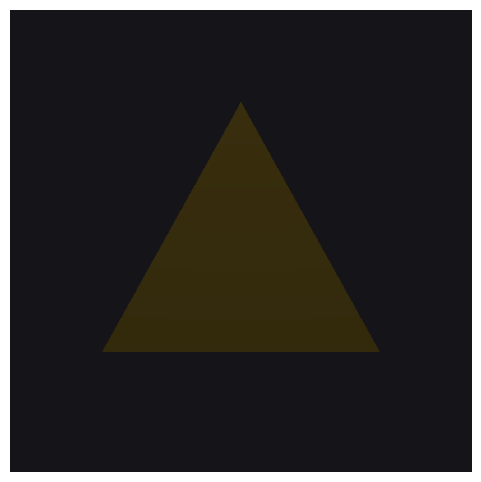

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Simple material
gold = Material(Vec3(1.0, 0.82, 0.25))

# Flat triangle in the z=4 plane
a = Vec3(-1.0, -0.8, 4.0)
b = Vec3( 0.0,  1.0, 4.0)
c = Vec3( 1.0, -0.8, 4.0)

# Face normal for this triangle would be roughly (0, 0, -1) or (0, 0, 1)
# depending on winding. We deliberately skew the normals outward in x/y.
# The important thing is that they are all still mostly pointing toward the camera.



triangle= Triangle(
    a=a,
    b=b,
    c=c,
    material=gold
)

camera = Camera(
    position=Vec3(0.0, 0.0, 0.0),
    look_at=Vec3(0.0, 0.0, 4.0),
    up=Vec3(0.0, 1.0, 0.0),
    fov_degrees=45,
    aspect=1.0
)

light_position = Vec3(0.0, 0.0, 2.0)


light = Lightsource(
    position=Vec3(0.0, 9.0, 3.0),
    intensity=Vec3(1.0, 1.0, 1.0),
    colour=Vec3(1.0, 1.0, 1.0)
)

img = render_img([triangle], camera, light, width=500, height=500)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()



# Exercise 2
Place some normals at the vertices of this triangle that are skewed outward from the actual normal of the flat triangle. When rendering with Phong, interpolate the normal vector within the triangle using Areal coordinates. Does your initially flat surface look like a slightly bowed outward surface now? What if you skew the vertex normals inward instead? (Some text answers expected here.)

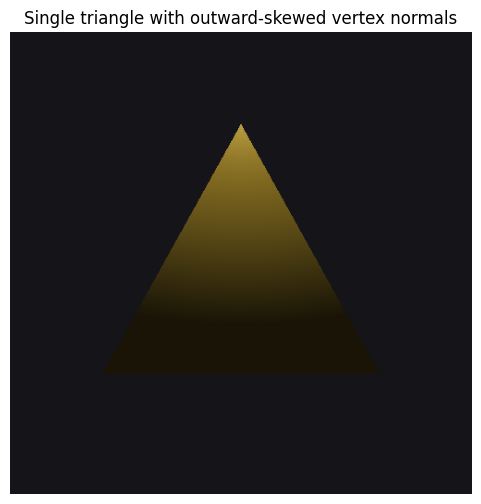

In [54]:
# Block 1: single triangle with outward-skewed vertex normals

import numpy as np
import matplotlib.pyplot as plt

# Simple material
gold = Material(Vec3(1.0, 0.82, 0.25))

# Flat triangle in the z=4 plane
a = Vec3(-1.0, -0.8, 4.0)
b = Vec3( 0.0,  1.0, 4.0)
c = Vec3( 1.0, -0.8, 4.0)

# Face normal for this triangle would be roughly (0, 0, -1) or (0, 0, 1)
# depending on winding. We deliberately skew the normals outward in x/y.
# The important thing is that they are all still mostly pointing toward the camera.

na_out = Vec3(-0.45, -0.25, -1.0).normalized()
nb_out = Vec3( 0.00,  0.45, -1.0).normalized()
nc_out = Vec3( 0.45, -0.25, -1.0).normalized()

triangle_outward = Triangle(
    a=a,
    b=b,
    c=c,
    material=gold,
    na=na_out,
    nb=nb_out,
    nc=nc_out
)

camera = Camera(
    position=Vec3(0.0, 0.0, 0.0),
    look_at=Vec3(0.0, 0.0, 4.0),
    up=Vec3(0.0, 1.0, 0.0),
    fov_degrees=45,
    aspect=1.0
)

light_position = Vec3(0.0, 0.0, 2.0)


light = Lightsource(
    position=Vec3(0.0, 9.0, 3.0),
    intensity=Vec3(1.0, 1.0, 1.0),
    colour=Vec3(1.0, 1.0, 1.0)
)

img = render_img([triangle_outward], camera, light, width=500, height=500)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Single triangle with outward-skewed vertex normals")
plt.axis("off")
plt.show()


Text(0.5, 1.0, 'Single triangle with inward-skewed vertex normals')

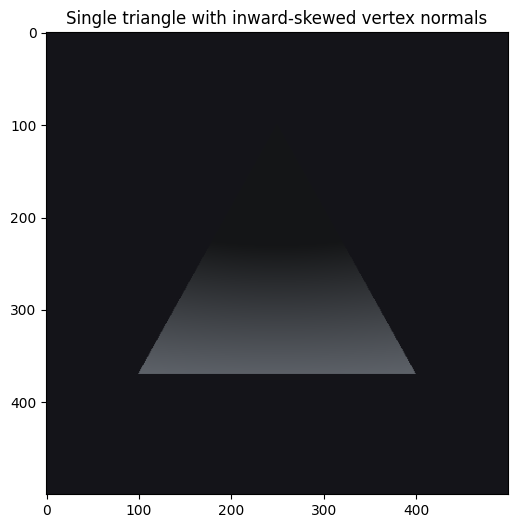

In [55]:
# Block 2: same triangle with inward-skewed vertex normals

import numpy as np
import matplotlib.pyplot as plt

silver = Material(Vec3(0.82, 0.86, 0.92))

a = Vec3(-1.0, -0.8, 4.0)
b = Vec3( 0.0,  1.0, 4.0)
c = Vec3( 1.0, -0.8, 4.0)

# Same idea as Block 1, but skewed inward instead of outward
na_in = Vec3( 0.45,  0.25, -1.0).normalized()
nb_in = Vec3( 0.00, -0.45, -1.0).normalized()
nc_in = Vec3(-0.45,  0.25, -1.0).normalized()

triangle_inward = Triangle(
    a=a,
    b=b,
    c=c,
    material=silver,
    na=na_in,
    nb=nb_in,
    nc=nc_in
)

camera = Camera(
    position=Vec3(0.0, 0.0, 0.0),
    look_at=Vec3(0.0, 0.0, 4.0),
    up=Vec3(0.0, 1.0, 0.0),
    fov_degrees=45,
    aspect=1.0
)


light = Lightsource(
    position=Vec3(0.0, 9.0, 3.0),
    intensity=Vec3(1.0, 1.0, 1.0),
    colour=Vec3(1.0, 1.0, 1.0)
)
img = render_img([triangle_inward], camera, light, width=500, height=500)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Single triangle with inward-skewed vertex normals")

The lighting in this scene is top down, so in the case of the outward skew we can see the top half of the triangle, but the curve casts a shadow over the lower half.
The inverse happens in the case of the inward bound triangle.
Though they aren't true shadows as it's just the dot product of the interpolated normal with the light so we can't see the exact shadow.

I would say they kind of look like they're outward bowed but maybe because of the choice of scene there's a slight sense of incongruity.

# Exercise 3
Render a tetrahedron of 4 triangles, set the vertex normals to point radially outward from the center of the tetrahedron. Try rendering with/without normal interpolation in the Phong model (without = triangle surface normal). Does it look as expected? (Text answer also expected.)

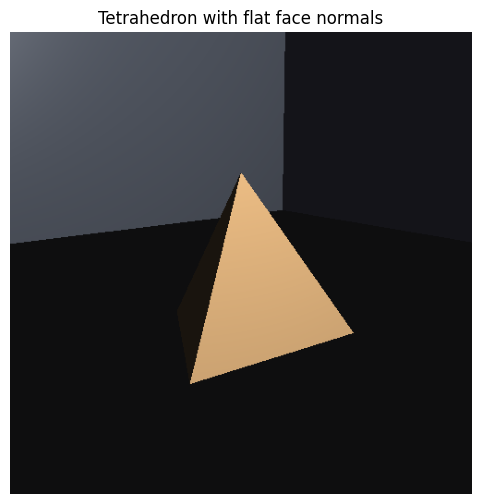

In [56]:
# Block 2: tetrahedron sitting like a D4, with flat face normals
# Includes a floor and back wall for better spatial context

import numpy as np
import matplotlib.pyplot as plt
import math

# ---------- Materials ----------
tetra_mat = Material(Vec3(1.00, 0.80, 0.56))
floor_mat = Material(Vec3(0.55, 0.55, 0.60))
wall_mat  = Material(Vec3(0.30, 0.32, 0.36))

# ---------- Regular tetrahedron sitting on one face ----------
s = 2.6
h_tri = math.sqrt(3) / 2 * s
z_centroid = h_tri / 3
tetra_height = math.sqrt(2/3) * s

v0 = Vec3(-s/2, 0.0, -z_centroid)
v1 = Vec3( s/2, 0.0, -z_centroid)
v2 = Vec3( 0.0, 0.0, 2*h_tri/3)
v3 = Vec3( 0.0, tetra_height, 0.0)

offset = Vec3(0.0, 0.0, 8.0)
v0 = v0 + offset
v1 = v1 + offset
v2 = v2 + offset
v3 = v3 + offset

tetra_tris = [
    Triangle(v0, v1, v2, tetra_mat),  # bottom face
    Triangle(v0, v3, v1, tetra_mat),
    Triangle(v1, v3, v2, tetra_mat),
    Triangle(v2, v3, v0, tetra_mat),
]

# ---------- Floor ----------
f0 = Vec3(-8.0, 0.0,  2.0)
f1 = Vec3( 8.0, 0.0,  2.0)
f2 = Vec3( 8.0, 0.0, 16.0)
f3 = Vec3(-8.0, 0.0, 16.0)

floor_tris = [
    Triangle(f0, f1, f2, floor_mat),
    Triangle(f0, f2, f3, floor_mat),
]

# ---------- Back wall ----------
w0 = Vec3(-8.0, 0.0, 16.0)
w1 = Vec3( 8.0, 0.0, 16.0)
w2 = Vec3( 8.0, 8.0, 16.0)
w3 = Vec3(-8.0, 8.0, 16.0)

wall_tris = [
    Triangle(w0, w2, w1, wall_mat),
    Triangle(w0, w3, w2, wall_mat),
]

objects = tetra_tris + floor_tris + wall_tris

# ---------- Camera ----------
camera = Camera(
    position=Vec3(4.8, 2.8, 2.0),
    look_at=Vec3(0.0, 1.0, 8.0),
    up=Vec3(0.0, 1.0, 0.0),
    fov_degrees=40,
    aspect=1.0
)

# ---------- Light ----------
light = Lightsource(
    position=Vec3(0.0, 9.0, 3.0),
    intensity=Vec3(1.0, 1.0, 1.0),
    colour=Vec3(1.0, 1.0, 1.0)
)

# ---------- Render ----------
img = render_img(objects, camera, light, width=500, height=500)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Tetrahedron with flat face normals")
plt.axis("off")
plt.show()


So far so good, it looks like I would expect a 4 sided dice to look, with very sharp edges.

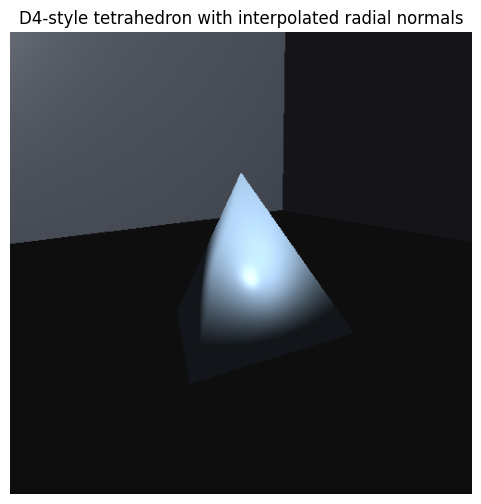

In [57]:
# Block 1: tetrahedron sitting like a D4, with interpolated radial normals
# Includes a floor and back wall for better spatial context

import numpy as np
import matplotlib.pyplot as plt
import math

# ---------- Materials ----------
tetra_mat = Material(Vec3(0.72, 0.86, 1.00))
floor_mat = Material(Vec3(0.55, 0.55, 0.60))
wall_mat  = Material(Vec3(0.30, 0.32, 0.36))

# ---------- Regular tetrahedron sitting on one face ----------
# Base face lies on y = 0, apex above it

s = 2.6  # side length
h_tri = math.sqrt(3) / 2 * s
z_centroid = h_tri / 3
tetra_height = math.sqrt(2/3) * s

# Base triangle (on the "table")
v0 = Vec3(-s/2, 0.0, -z_centroid)
v1 = Vec3( s/2, 0.0, -z_centroid)
v2 = Vec3( 0.0, 0.0, 2*h_tri/3)

# Apex above the centroid of the base
v3 = Vec3(0.0, tetra_height, 0.0)

# Move the whole tetrahedron forward into view
offset = Vec3(0.0, 0.0, 8.0)
v0 = v0 + offset
v1 = v1 + offset
v2 = v2 + offset
v3 = v3 + offset

# Center for radial normals
center = Vec3(
    (v0.x + v1.x + v2.x + v3.x) / 4.0,
    (v0.y + v1.y + v2.y + v3.y) / 4.0,
    (v0.z + v1.z + v2.z + v3.z) / 4.0
)

n0 = (v0 - center).normalized()
n1 = (v1 - center).normalized()
n2 = (v2 - center).normalized()
n3 = (v3 - center).normalized()

tetra_tris = [
    Triangle(v0, v1, v2, tetra_mat, na=n0, nb=n1, nc=n2),  # bottom face
    Triangle(v0, v3, v1, tetra_mat, na=n0, nb=n3, nc=n1),
    Triangle(v1, v3, v2, tetra_mat, na=n1, nb=n3, nc=n2),
    Triangle(v2, v3, v0, tetra_mat, na=n2, nb=n3, nc=n0),
]

# ---------- Floor ----------
f0 = Vec3(-8.0, 0.0,  2.0)
f1 = Vec3( 8.0, 0.0,  2.0)
f2 = Vec3( 8.0, 0.0, 16.0)
f3 = Vec3(-8.0, 0.0, 16.0)

floor_tris = [
    Triangle(f0, f1, f2, floor_mat),
    Triangle(f0, f2, f3, floor_mat),
]

# ---------- Back wall ----------
w0 = Vec3(-8.0, 0.0, 16.0)
w1 = Vec3( 8.0, 0.0, 16.0)
w2 = Vec3( 8.0, 8.0, 16.0)
w3 = Vec3(-8.0, 8.0, 16.0)

wall_tris = [
    Triangle(w0, w2, w1, wall_mat),
    Triangle(w0, w3, w2, wall_mat),
]

objects = tetra_tris + floor_tris + wall_tris

# ---------- Camera ----------
camera = Camera(
    position=Vec3(4.8, 2.8, 2.0),
    look_at=Vec3(0.0, 1.0, 8.0),
    up=Vec3(0.0, 1.0, 0.0),
    fov_degrees=40,
    aspect=1.0
)

# ---------- Light ----------

light = Lightsource(
    position=Vec3(0.0, 9.0, 3.0),
    intensity=Vec3(1.0, 1.0, 1.0),
    colour=Vec3(1.0, 1.0, 1.0)
)

# ---------- Optional: point-light Phong shader ----------
# Use this version if your current phong_shade still uses light.direction globally.


# ---------- Render ----------
img = render_img(objects, camera, light, width=500, height=500)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("D4-style tetrahedron with interpolated radial normals")
plt.axis("off")
plt.show()

Again I'm quite content with the way it looks like a rounded tetrahedron, though perhaps some more refinement would be possible as the shading is still quite rough. That said I would say it looks as expected.

The rendering is starting to take a long time as I foolishly used loops, for the next exercise I'll build a rendering function that's fully vectorised.

# Exercise 4
How could you speed up the code so that you don't have to check O(1000) of triangles for each ray, when typically only a few triangles need to be checked for intersection? (Text Question, you don't have to implement this for the question below!)


To speed up the ray–triangle intersection tests, the triangles could be organized spatially so that each ray only needs to check nearby triangles instead of all of them. In the current brute-force approach, every ray checks against all triangles in the scene, which can be expensive if there are hundreds or thousands of triangles.

One idea would be to sort triangles based on their position in space. For example, if Ray 
n intersects triangle 30, then the next ray will likely intersect triangles in a similar region. If the triangles are spatially ordered, we could check triangles around that region (for example triangles 20–40) instead of checking the entire list. For regular scenes it should be possible to estimate how large this range needs to be to maintain good rendering quality.

A more robust approach would be to divide the scene into an 
N×N grid. Each triangle (or its vertices) would be assigned to the grid cells it overlaps. When tracing a ray, we would first determine which grid cell the ray passes through and then only test intersections with triangles stored in that cell, possibly also checking neighboring cells. Since each cell would contain far fewer triangles than the whole scene, this would significantly reduce the number of intersection tests needed per ray.

This type of spatial partitioning helps avoid unnecessary checks and makes the rendering process much faster.

# Bonus Exercise
Render the Utah teapot both shiny and matte clay color. The triangulation is given in a data file in the "Shared" folder in the Teams. (teapot.zip)

In [58]:
#read in utah teapot.txt file
with open("...", "r") as f:     # replace "..." with the path to your extracted teapot.txt file
    lines = f.readlines()
    vertices = []
    triangles = []
    for line in lines:
        parts = line.split()
        if len(parts) == 0:
            continue
        if parts[0] == "v":
            x, y, z = map(float, parts[1:4])
            vertices.append(Vec3(x, y, z))
        elif parts[0] == "f":
            idx1, idx2, idx3 = map(int, parts[1:4])
            triangles.append((idx1 - 1, idx2 - 1, idx3 - 1))  # convert to 0-based index
teapot_tris = []
for idx1, idx2, idx3 in triangles:
    v1 = vertices[idx1]
    v2 = vertices[idx2]
    v3 = vertices[idx3]
    teapot_tris.append(Triangle(v1, v2, v3, Material(Vec3(0.8, 0.6, 0.4))))

print(f"Loaded teapot with {len(vertices)} vertices and {len(teapot_tris)} triangles")




PermissionError: [Errno 13] Permission denied: '...'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helpers ----------

def vec3_to_np(v):
    return np.array([v.x, v.y, v.z], dtype=np.float32)

def normalize_np(x, eps=1e-8):
    n = np.linalg.norm(x, axis=-1, keepdims=True)
    return x / np.maximum(n, eps)

def build_triangle_arrays(tris):
    v0 = np.array([vec3_to_np(t.a) for t in tris], dtype=np.float32)
    v1 = np.array([vec3_to_np(t.b) for t in tris], dtype=np.float32)
    v2 = np.array([vec3_to_np(t.c) for t in tris], dtype=np.float32)

    e1 = v1 - v0
    e2 = v2 - v0

    face_normals = normalize_np(np.cross(e1, e2))

    colours = np.array(
        [vec3_to_np(t.material.colour) for t in tris],
        dtype=np.float32
    )

    # Optional smooth normals if present
    has_vertex_normals = all(
        hasattr(t, "na") and hasattr(t, "nb") and hasattr(t, "nc")
        and t.na is not None and t.nb is not None and t.nc is not None
        for t in tris
    )

    if has_vertex_normals:
        na = np.array([vec3_to_np(t.na) for t in tris], dtype=np.float32)
        nb = np.array([vec3_to_np(t.nb) for t in tris], dtype=np.float32)
        nc = np.array([vec3_to_np(t.nc) for t in tris], dtype=np.float32)
    else:
        na = nb = nc = None

    return {
        "v0": v0,
        "v1": v1,
        "v2": v2,
        "e1": e1,
        "e2": e2,
        "face_normals": face_normals,
        "colours": colours,
        "na": na,
        "nb": nb,
        "nc": nc,
    }

def generate_camera_rays(camera, width, height):
    eye = vec3_to_np(camera.position)
    center = vec3_to_np(camera.look_at)
    up = vec3_to_np(camera.up)

    forward = center - eye
    forward = forward / np.linalg.norm(forward)

    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)

    true_up = np.cross(right, forward)
    true_up = true_up / np.linalg.norm(true_up)

    fov_rad = np.deg2rad(camera.fov_degrees)
    half_h = np.tan(fov_rad / 2.0)
    half_w = camera.aspect * half_h

    xs = np.linspace(-half_w, half_w, width, dtype=np.float32)
    ys = np.linspace(half_h, -half_h, height, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)

    dirs = (
        forward[None, None, :]
        + xx[..., None] * right[None, None, :]
        + yy[..., None] * true_up[None, None, :]
    )
    dirs = normalize_np(dirs)

    origins = np.broadcast_to(eye, dirs.shape).copy()
    return origins, dirs

# ---------- Vectorized render ----------

def render_mesh_numpy(tris, camera, light, width=500, height=500,
                      bg=(0.05, 0.05, 0.07), ray_chunk=512,
                      ambient_strength=0.10, spec_strength=0.25, shininess=48.0):
    mesh = build_triangle_arrays(tris)

    v0 = mesh["v0"]                  # (T, 3)
    e1 = mesh["e1"]                  # (T, 3)
    e2 = mesh["e2"]                  # (T, 3)
    face_normals = mesh["face_normals"]
    colours = mesh["colours"]
    na, nb, nc = mesh["na"], mesh["nb"], mesh["nc"]

    light_pos = vec3_to_np(light.position)
    light_col = vec3_to_np(light.colour)
    eye = vec3_to_np(camera.position)

    origins, dirs_img = generate_camera_rays(camera, width, height)
    rays = dirs_img.reshape(-1, 3)
    num_rays = rays.shape[0]

    img = np.zeros((num_rays, 3), dtype=np.float32)
    img[:] = np.array(bg, dtype=np.float32)

    eps = 1e-6

    # Since all rays share the same origin, this can be precomputed per triangle
    tvec_const = eye[None, :] - v0               # (T, 3)
    qvec_const = np.cross(tvec_const, e1)        # (T, 3)

    for start in range(0, num_rays, ray_chunk):
        end = min(start + ray_chunk, num_rays)
        d = rays[start:end]                      # (R, 3)
        R = d.shape[0]

        # Möller–Trumbore in broadcasted form
        pvec = np.cross(d[:, None, :], e2[None, :, :])               # (R, T, 3)
        det = np.sum(e1[None, :, :] * pvec, axis=-1)                 # (R, T)

        valid_det = np.abs(det) > eps
        inv_det = np.zeros_like(det, dtype=np.float32)
        inv_det[valid_det] = 1.0 / det[valid_det]

        u = np.sum(tvec_const[None, :, :] * pvec, axis=-1) * inv_det # (R, T)
        v = np.sum(d[:, None, :] * qvec_const[None, :, :], axis=-1) * inv_det
        t = np.sum(e2[None, :, :] * qvec_const[None, :, :], axis=-1) * inv_det

        hit_mask = (
            valid_det &
            (u >= 0.0) &
            (v >= 0.0) &
            ((u + v) <= 1.0) &
            (t > eps)
        )

        t_valid = np.where(hit_mask, t, np.inf)
        tri_idx = np.argmin(t_valid, axis=1)                         # (R,)
        t_min = t_valid[np.arange(R), tri_idx]                       # (R,)
        hit_any = np.isfinite(t_min)

        if not np.any(hit_any):
            continue

        tri_hit = tri_idx[hit_any]
        t_hit = t_min[hit_any]
        d_hit = d[hit_any]

        u_hit = u[np.arange(R), tri_idx][hit_any]
        v_hit = v[np.arange(R), tri_idx][hit_any]
        w_hit = 1.0 - u_hit - v_hit

        p_hit = eye[None, :] + d_hit * t_hit[:, None]

        # Shading normals
        if na is not None:
            n_hit = (
                na[tri_hit] * w_hit[:, None] +
                nb[tri_hit] * u_hit[:, None] +
                nc[tri_hit] * v_hit[:, None]
            )
            n_hit = normalize_np(n_hit)

            # Keep interpolated normal in same hemisphere as face normal
            face_n = face_normals[tri_hit]
            flip = np.sum(n_hit * face_n, axis=1) < 0.0
            n_hit[flip] *= -1.0
        else:
            n_hit = face_normals[tri_hit]

        base_col = colours[tri_hit]

        # Point-light Phong shading
        l = normalize_np(light_pos[None, :] - p_hit)
        vdir = normalize_np(eye[None, :] - p_hit)
        h = normalize_np(l + vdir)

        ambient = base_col * ambient_strength

        diff = np.maximum(np.sum(n_hit * l, axis=1, keepdims=True), 0.0)
        diffuse = base_col * diff

        spec = np.maximum(np.sum(n_hit * h, axis=1, keepdims=True), 0.0) ** shininess
        specular = light_col[None, :] * (spec_strength * spec)

        shaded = (ambient + diffuse) * light_col[None, :] + specular
        shaded = np.clip(shaded, 0.0, 1.0)

        img[start:end][hit_any] = shaded

    return img.reshape(height, width, 3)

def build_smooth_vertex_normal_mesh(tris, decimals=6):
    def key(v):
        return (round(v.x, decimals), round(v.y, decimals), round(v.z, decimals))

    # Accumulate face normals at shared vertex positions
    accum = {}
    for tri in tris:
        fn = (tri.b - tri.a).cross(tri.c - tri.a).normalized()

        for v in (tri.a, tri.b, tri.c):
            k = key(v)
            if k not in accum:
                accum[k] = Vec3(0.0, 0.0, 0.0)
            accum[k] = accum[k] + fn

    # Normalize accumulated normals
    smooth_normals = {}
    for k, n in accum.items():
        smooth_normals[k] = n.normalized()

    # Rebuild triangles with interpolated vertex normals
    smooth_tris = []
    for tri in tris:
        na = smooth_normals[key(tri.a)]
        nb = smooth_normals[key(tri.b)]
        nc = smooth_normals[key(tri.c)]

        smooth_tris.append(
            Triangle(
                tri.a, tri.b, tri.c, tri.material,
                na=na, nb=nb, nc=nc
            )
        )

    return smooth_tris

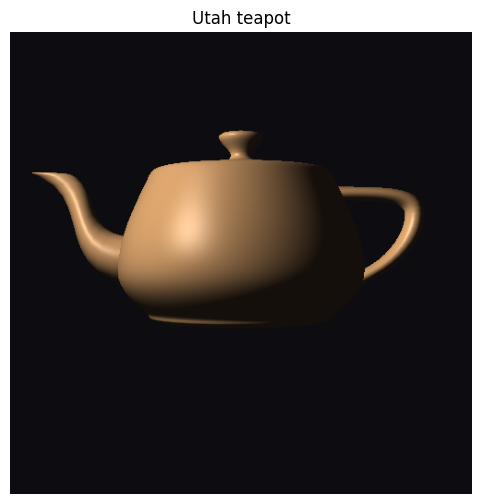

In [ ]:
camera = Camera(
    position=Vec3(0.0, 1.0, -12.0),
    look_at=Vec3(0.0, 1.0, 0.0),
    up=Vec3(0.0, 1.0, 0.0),
    fov_degrees=35,
    aspect=1.0
)
light = Lightsource(
    position=Vec3(5.0, 5.0, -5.0),
    intensity=Vec3(1.0, 1.0, 1.0),
    colour=Vec3(1.0, 1.0, 1.0)
)

smooth_teapot_tris = build_smooth_vertex_normal_mesh(teapot_tris)

img = render_mesh_numpy(
    smooth_teapot_tris,
    camera,
    light,
    width=500,
    height=500,
    ray_chunk=512   # try 256, 512, or 1024 depending on RAM
)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Utah teapot")
plt.show()

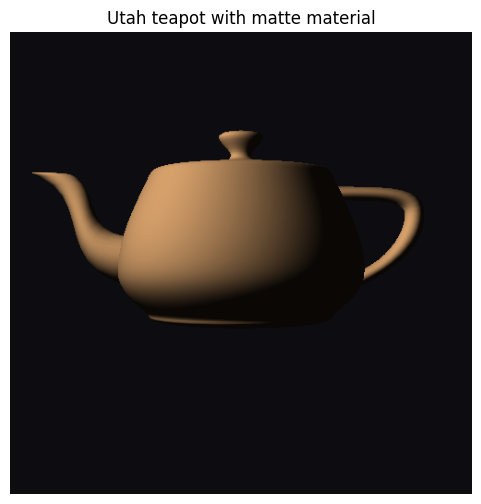

In [ ]:
#now to make the material matte, we can set the specular strength to 0 and reduce the ambient strength
matte_img = render_mesh_numpy(
    smooth_teapot_tris,
    camera,
    light,
    width=500,
    height=500,
    ray_chunk=512,
    ambient_strength=0.05,  # reduce ambient for less shine
    spec_strength=0.0       # no specular highlights
)
plt.figure(figsize=(6, 6))
plt.imshow(matte_img)
plt.axis("off")
plt.title("Utah teapot with matte material")
plt.show()
